<a href="https://colab.research.google.com/github/gracella12/PCD_Assignment/blob/PCD_Assignment02/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Enhancement

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

##Low Contrass Image
Teknik: Contrast Strech

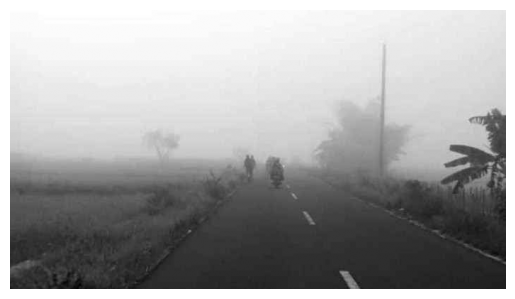

In [16]:
low_path = '/content/low_contras.jpg'
low_contrass = cv2.imread(low_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(low_contrass, cmap='gray')
plt.axis('off')
plt.show()

Height: 394, Width: 700
Intensity Level: 172


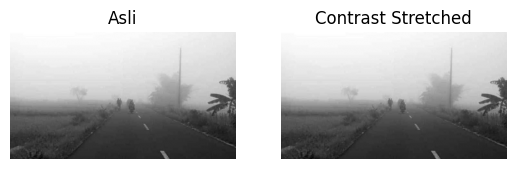

In [17]:
#image dimension
height, width = low_contrass.shape
print(f"Height: {height}, Width: {width}")

#intensity level
intensity_level = np.max(low_contrass) - np.min(low_contrass)
min = np.min(low_contrass)
max = np.max(low_contrass)
print(f"Intensity Level: {intensity_level}")

#contrass streching
p_out = ((low_contrass - min) / (max - min)) * 255
p_out = np.uint8(p_out)

# tampilkan hasil
plt.subplot(1,2,1)
plt.imshow(low_contrass, cmap='gray')
plt.title("Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(p_out, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')

plt.show()

In [18]:
print("Pixel asli (100,200):", low_contrass[100,200])
print("Pixel hasil (100,200):", p_out[100,200])

print("Min hasil:", np.min(p_out))
print("Max hasil:", np.max(p_out))


Pixel asli (100,200): 207
Pixel hasil (100,200): 237
Min hasil: 0
Max hasil: 255


Analisis:
Meskipun tidak begitu terlihat jelas, tetapi dari nilai menunjukkan adanya contrast stretching dimana hasil dari enchance contrastnya lebih tinggi dibandingkan citra asli

##Blur Image
Using laplace filter to sharpen


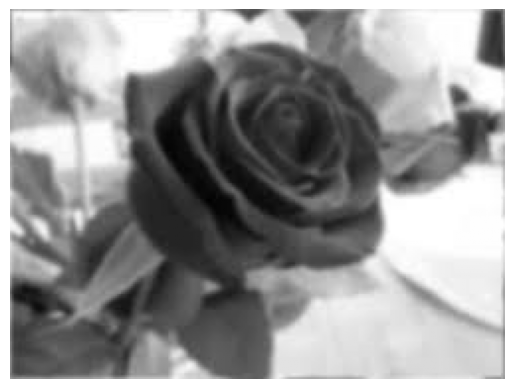

In [46]:
blur_path = '/content/blur.jpg'
blur = cv2.imread(blur_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(blur, cmap='gray')
plt.axis('off')
plt.show()

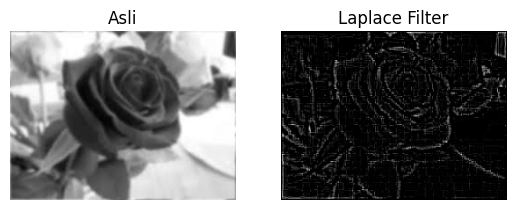

In [47]:
# image dimension
height, width = blur.shape

# Laplace manual
out = np.zeros((height, width), dtype=np.float32)
for i in range(1, height-1):
    for j in range(1, width-1):
        center = float(blur[i, j])
        top = float(blur[i-1, j])
        bottom = float(blur[i+1, j])
        left = float(blur[i, j-1])
        right = float(blur[i, j+1])
        top_left = float(blur[i-1, j-1])
        top_right = float(blur[i-1, j+1])
        bottom_left = float(blur[i+1, j-1])
        bottom_right = float(blur[i+1, j+1])

        out[i, j] = (-8 * center) + (top + bottom + left + right +
                                     top_left + top_right + bottom_left + bottom_right)

# konversi ke uint8
laplace_img = np.clip(out, 0, 255).astype(np.uint8)

# tampilkan
plt.subplot(1,2,1)
plt.imshow(blur, cmap='gray')
plt.title("Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(laplace_img, cmap='gray')
plt.title("Laplace Filter")
plt.axis('off')
plt.show()


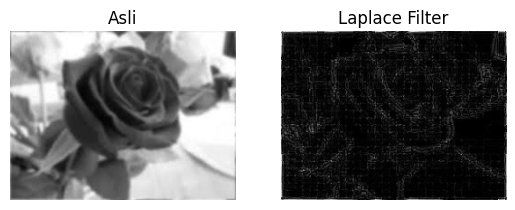

In [48]:
#using library
laplace = cv2.Laplacian(blur, cv2.CV_64F)
laplace = np.uint8(np.absolute(laplace)) #ubah ke rentang 0-255

# tampilkan
plt.subplot(1,2,1)
plt.imshow(blur, cmap='gray')
plt.title("Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(laplace, cmap='gray')
plt.title("Laplace Filter")
plt.axis('off')
plt.show()

Analisis: Dapat dilihat, dengan menggunakan laplace, gambar yang blur dapat terdeteksi tepiannya. Hal ini memperlihatkan laplace, terutama laplace murni dapat membantu dalam menegaskan tepi/edge sehingga nantinya akan mudah dalam proses deteksi

##Bright Image
To handle bright image, we can use histogram equality

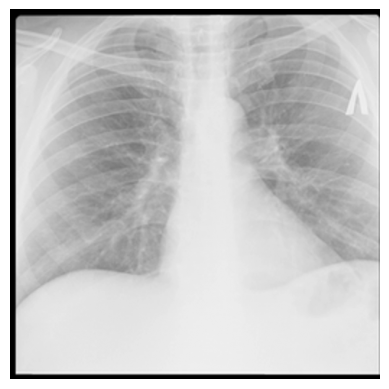

In [25]:
bright_path = '/content/bright.png'
bright_hist = cv2.imread(bright_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(bright_hist, cmap='gray')
plt.axis('off')
plt.show()

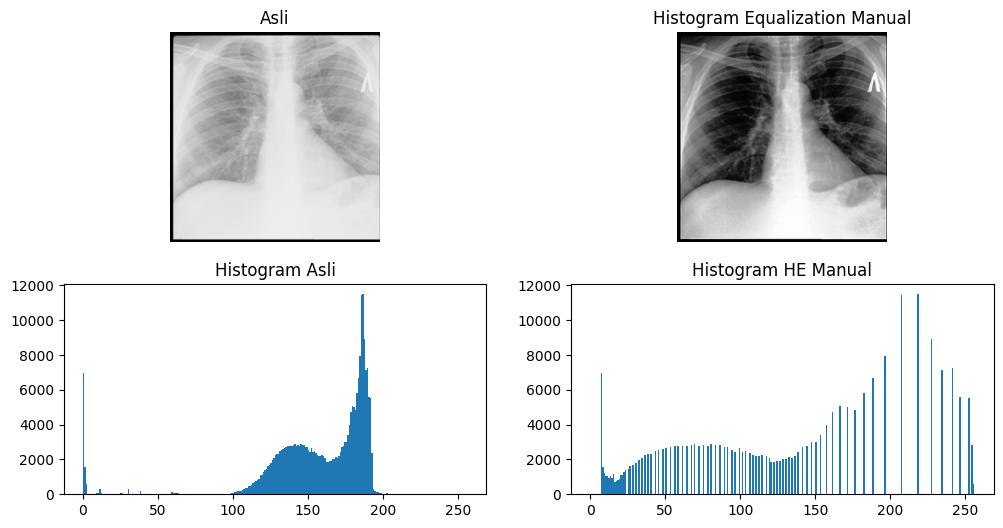

In [26]:
#Histogram Equalization manual
#1. define histogram
hist, bins = np.histogram(bright_hist.flatten(), bins=256, range=[0,256])

# 2. Normalisasi histogram (PDF)
pdf = hist / np.sum(hist)

# 3. Hitung CDF
cdf = np.cumsum(pdf)

# 4. Mapping transformasi (0–255)
transformation_map = np.round(cdf * 255).astype(np.uint8)

# 5. Apply mapping ke citra
he_manual = transformation_map[bright_hist]

# Visualisasi Gambar
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(bright_hist, cmap='gray')
plt.title("Asli")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(he_manual, cmap='gray')
plt.title("Histogram Equalization Manual")
plt.axis('off')

#Visualisasi histogram
plt.subplot(2,2,3)
plt.hist(bright_hist.ravel(), bins=256, range=[0,256])
plt.title("Histogram Asli")

plt.subplot(2,2,4)
plt.hist(he_manual.ravel(), bins=256, range=[0,256])
plt.title("Histogram HE Manual")

plt.show()

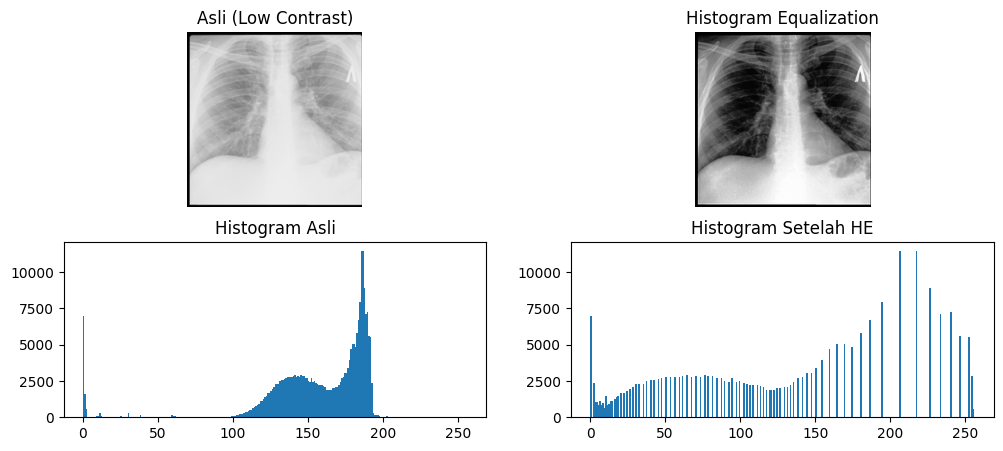

In [38]:
#histogram equalization using library
new_img = cv2.equalizeHist(bright_hist)

# tampilkan hasil
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(bright_hist, cmap='gray')
plt.title("Asli (Low Contrast)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(new_img, cmap='gray')
plt.title("Histogram Equalization")
plt.axis('off')

# histogram sebelum
plt.subplot(2,2,3)
plt.hist(bright_hist.ravel(), bins=256, range=[0,256])
plt.title("Histogram Asli")

# histogram sesudah
plt.subplot(2,2,4)
plt.hist(new_img.ravel(), bins=256, range=[0,256])
plt.title("Histogram Setelah HE")

plt.show()

Analisis: Diketahui bahwa gambar bright memiliki rentang intensitas pada 100-200 dan berdasarkan histogram, dapat dilihat bahwa nilainya banyak mengumpul pada rentang intensitas tinggi dibandingkan intensitas rendah. Hal ini membuat detail pada x-ray menjadi kurang terlihat. Dengan menggunakan histogram equalization, dimana intensitasnya dibuat menjadi lebih tersebar, dapat dilihat bahwa detailnya menjadi lebih terlihat.

##Dark Image

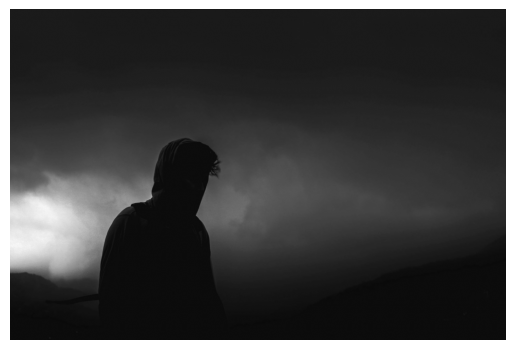

In [36]:
dark_path = '/content/dark.jpg'
dark = cv2.imread(dark_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(dark, cmap='gray')
plt.axis('off')
plt.show()

Logaritmic transformation

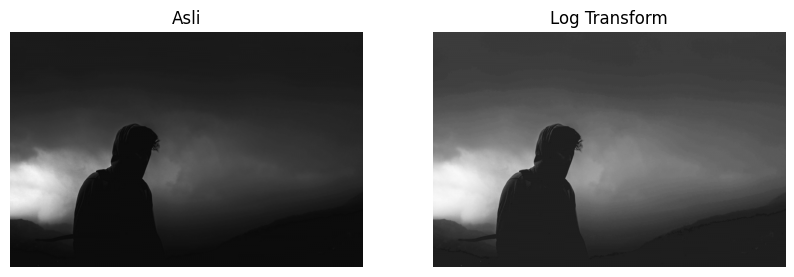

In [39]:
#image dimension
height, width = dark.shape

# Konstanta c untuk log transform
c = 255 / np.log(1 + np.max(dark))

#logaritmic
out = np.zeros((height,width), dtype=np.float32)
for i in range(height):
    for j in range(width):
        r = float(dark[i,j])
        s = c * np.log(1.0 + r)
        out[i,j] = s
out = np.clip(out,0,255).astype(np.uint8)

#plot perbandingan
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(dark, cmap='gray')
plt.title("Asli")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(out, cmap='gray')
plt.title("Log Transform")
plt.axis('off')

plt.show()

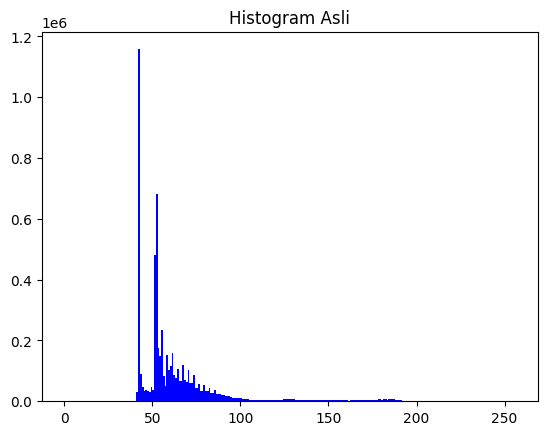

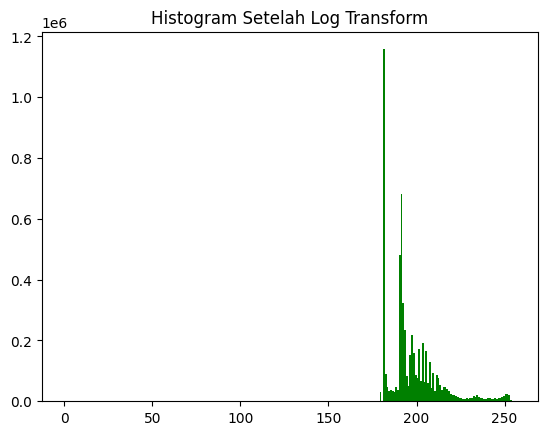

In [43]:
plt.hist(dark.ravel(), bins=256, range=[0,256], color='blue')
plt.title("Histogram Asli")
plt.show()

plt.hist(out.ravel(), bins=256, range=[0,256], color='green')
plt.title("Histogram Setelah Log Transform")
plt.show()


Analisis: Pada dark image (gambar yang memiliki intensitas rendah), melalui histogram yang ada dapat dilihat bahwa persebaran nilai intensitasnya berada di rentang yang rendah. Ketika digunakan log transform, sebaran intensitas berubah. Sebaran intensitas sekarang berada di range tinggi yang artinya gambar menjadi lebih terang

Histogram Equalization

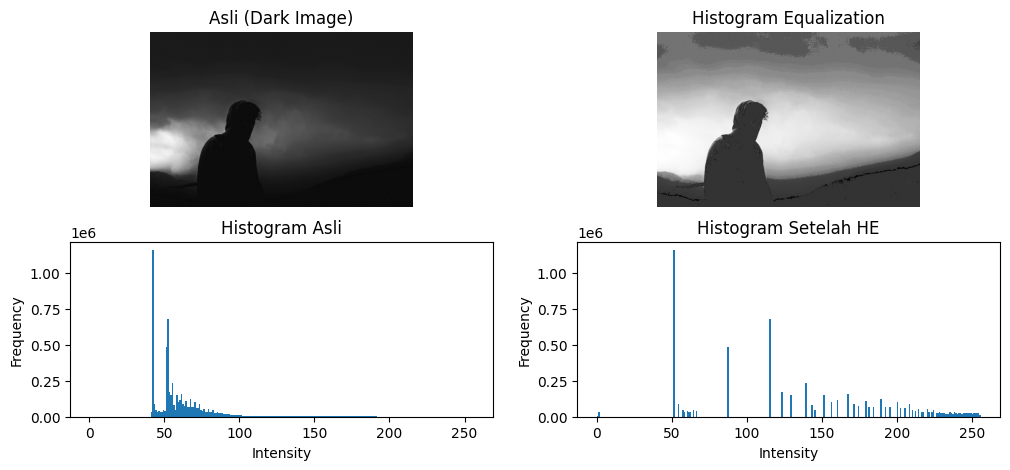

In [44]:
#histogram equalization using library
dark_equalized = cv2.equalizeHist(dark)

# tampilkan hasil
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(dark, cmap='gray')
plt.title("Asli (Dark Image)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(dark_equalized, cmap='gray')
plt.title("Histogram Equalization")
plt.axis('off')

# histogram sebelum
plt.subplot(2,2,3)
plt.hist(dark.ravel(), bins=256, range=[0,256])
plt.title("Histogram Asli")
plt.xlabel("Intensity")
plt.ylabel("Frequency")


# histogram sesudah
plt.subplot(2,2,4)
plt.hist(dark_equalized.ravel(), bins=256, range=[0,256])
plt.title("Histogram Setelah HE")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

##Noise
Using the median filter method

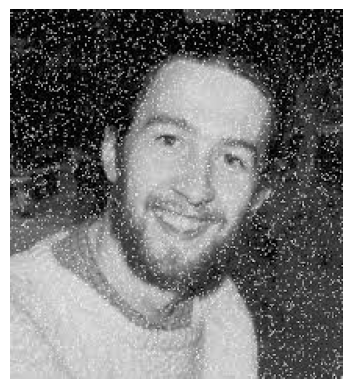

In [49]:
noise_path = '/content/noise.jpg'
noise = cv2.imread(noise_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(noise, cmap='gray')
plt.axis('off')
plt.show()

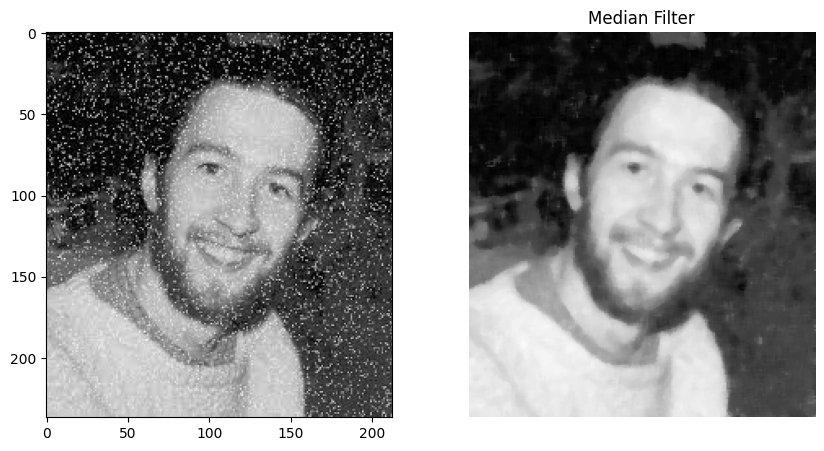

In [50]:
#image dimension
height, width = noise.shape

#median filter
median = cv2.medianBlur(noise, 5)

#plot perbandingan
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(noise, cmap='gray')

plt.subplot(1,2,2)
plt.imshow(median, cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.show()

Analisis: Median filter menggunakan nilai tengah dari matriks NxN yang membuat nilainya lebih rata sehingga dapat dilihat bahwa yang awalnya banyak salt and pepper noise, ketika median filter diimplementasikan, noise pada gambar tersebut menjadi hilang.